In [1]:
import subprocess
import sys
import re
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp
import pandas as pd
import numpy as np
import spacehub_calc
import matplotlib.animation as animation


In [2]:
title = "TwoBodyNewtonian"

cppFile = f"simulations/{title}.cpp"
execFile = cppFile[:-4]
makecmd = f"g++ -std=c++17 -O3 -pthread {cppFile} -o {execFile}"
simresultFile = f"simulation_results/test-output.txt"


#clean
result = subprocess.run(
f"rm {execFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)

result = subprocess.run(
f"rm {simresultFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    
print("Cleaned")

#make
result = subprocess.run(
makecmd, 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise OSError("Make error")
print("Made")

#run sim
result = subprocess.run(
f"./{execFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)

#Rename output file
result = subprocess.run(
f"mv simulation_results/Result.txt {simresultFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)


rm: cannot remove 'simulation_results/test-output.txt': No such file or directory

Cleaned
Made
Executed with exit code 0
Simulation complete
Executed with exit code 0



In [3]:
simpleOrbit = spacehub_calc.TwoBodyOrbit(simresultFile, 0, 1)

In [4]:
print(simpleOrbit)

Initial (t=0) Conditions:
a: 4.999999999999996AU
e: 0.2999999999999992
i: 45.00000000000001deg
Longtiude of Ascending Node: 270.0000014787793deg
Argument of Periapsis: 59.99999999999992deg
True Anomaly: 0.0deg
Orbital Separation: 3.499999999999999



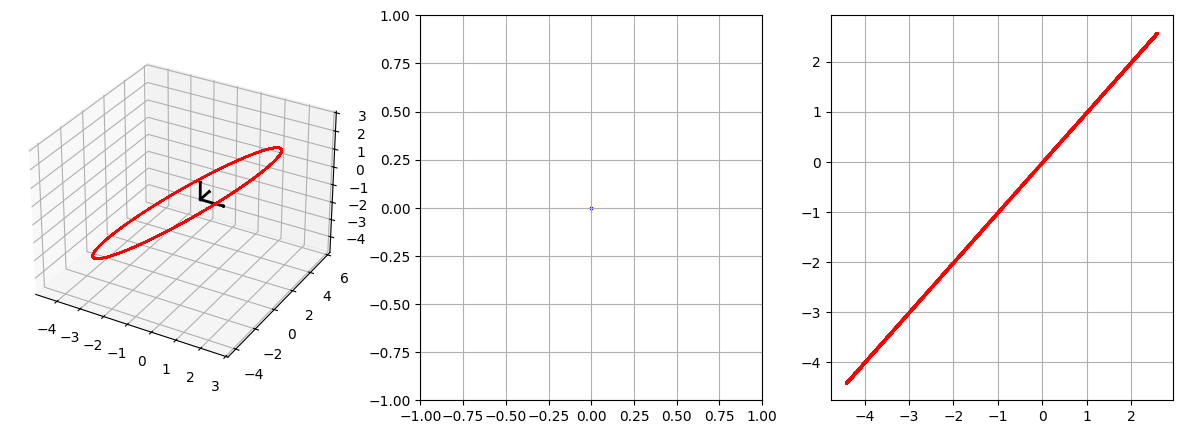

In [5]:
fig, axes = simpleOrbit.plot_orbit_3panel()

(<Figure size 1500x1000 with 6 Axes>,
 array([<Axes: title={'center': 'Eccentricity'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$e$'>,
        <Axes: title={'center': 'Inclination'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$i$ (deg)'>,
        <Axes: title={'center': 'Separation'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$||R||$ ($AU$)'>,
        <Axes: title={'center': 'Longitude of Ascending Node'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$\\Omega$ (deg)'>,
        <Axes: title={'center': 'Semi-major Axis'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$a$ (AU)'>,
        <Axes: title={'center': 'Argument of Periapsis'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$\\omega$ (deg)'>],
       dtype=object))

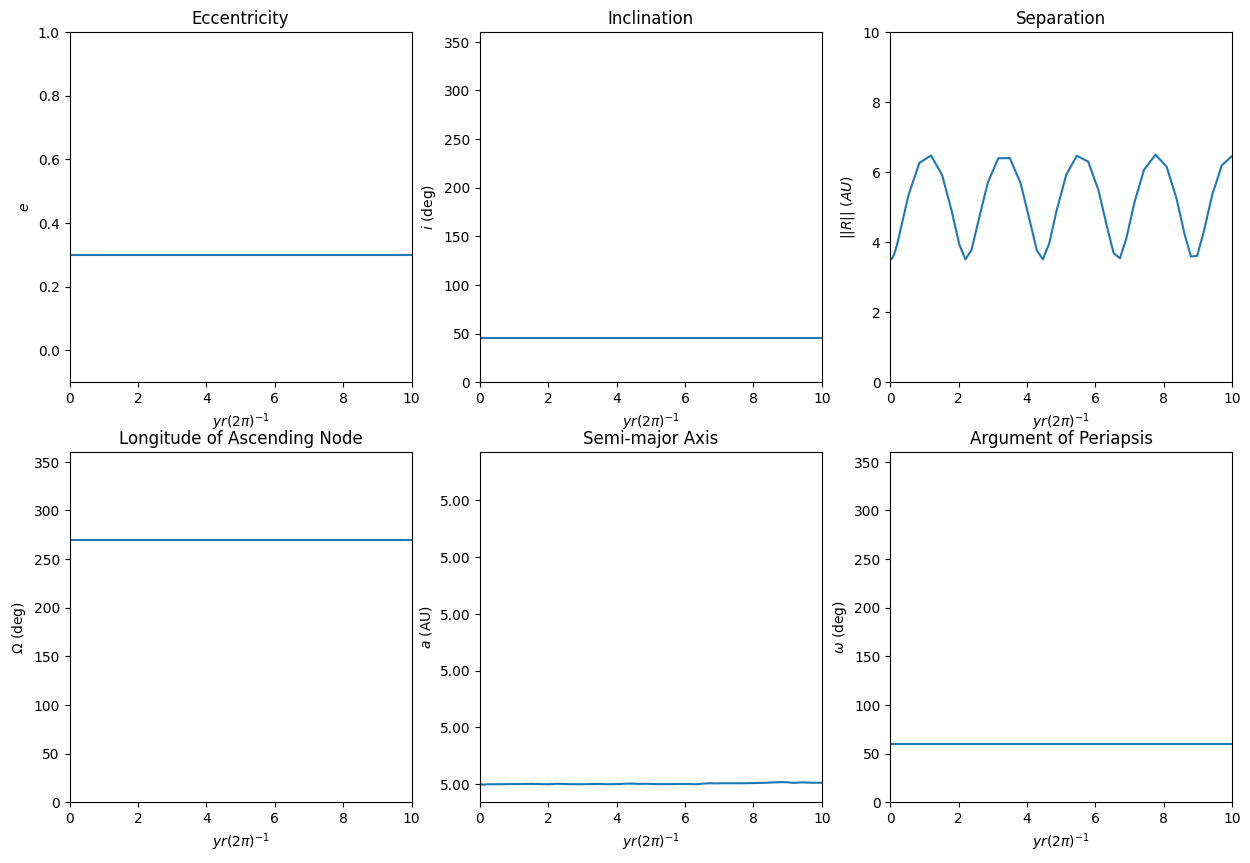

In [6]:
simpleOrbit.plot_keplerian_evolution_basic(xlim=[0,10])


In [7]:
simpleOrbit.data

,time,id,mass,px,py,pz,vx,vy,vz,p,v
0,0.000000,0,1000.0,0.002141,-0.001748,0.002141,0.006810,0.016682,0.006810,0.003497,0.019263
1,0.000000,1,1.0,-2.141162,1.748252,-2.141162,-6.810447,-16.682120,-6.810447,3.496503,19.262853
2,0.023002,0,1000.0,0.002284,-0.001355,0.002284,0.005623,0.017515,0.005623,0.003503,0.019235
3,0.023002,1,1.0,-2.284293,1.354549,-2.284293,-5.623185,-17.514662,-5.623185,3.502969,19.235483
4,0.058723,0,1000.0,0.002451,-0.000712,0.002451,0.003680,0.018364,0.003680,0.003538,0.019087
...,...,...,...,...,...,...,...,...,...,...,...
49681,6283.166754,1,1.0,1.871150,3.833304,1.871150,-10.194265,4.568201,-10.194265,4.657963,15.123311
49682,6283.185144,0,1000.0,-0.001681,-0.003911,-0.001681,0.010525,-0.003846,0.010525,0.004576,0.015374
49683,6283.185144,1,1.0,1.680609,3.910750,1.680609,-10.525379,3.845852,-10.525379,4.576337,15.373932
49684,6283.185307,0,1000.0,-0.001679,-0.003911,-0.001679,0.010528,-0.003839,0.010528,0.004576,0.015376
